# Person C: gene-grouped CV, modelling and evaluation on data0

Run this notebook from top to bottom with the project's `.venv` kernel. It reuses the parser and feature engineering modules,
then implements every technical item in the Person C checklist. All experiment decisions use the training partition's **5-fold GroupKFold by gene_id**.
Validation sets the classification threshold; the historical test partition is used for a final descriptive evaluation only.

| Deliverable | Implementation below |
|---|---|
| GroupKFold CV; ROC AUC and PR AUC mean ± sd | Sections 8–11; identical folds for every experiment |
| Gradient-boosted tree baseline on mean features | E01: nine raw signal means, no class weights |
| Class imbalance | Paired unweighted/weighted HGB and XGBoost; fold-local class weights / scale_pos_weight |
| Hyperparameter tuning and model comparison | Fixed baselines plus reproducible random searches for HGB and XGBoost |
| Experiment log | Per-fold results and experiment summaries, parameter changes, timestamps, immutable run directories |
| Final model recommendation | Highest mean CV AP, with ROC-AUC as the tie-breaker; recommendation and model bundle saved |

**Samples:** one `(transcript_id, transcript_position)` site, one binary label. All reads for a gene stay together.
The common X table contains **153 engineered features + 9 raw mean features = 162 columns**.
Each model pipeline explicitly selects its feature subset: raw-mean baseline (9), sequence-only (47), or engineered full set (153).

**Scope:** data0 only. Keep data1 separate because of site overlap, and data2 separate because it represents synthetic mixtures. Its annotated labels are binarized as `label_original > 0`.
The original deadlines were 30 September–4 October 2026. Actual execution timestamps are logged; this notebook does not claim earlier work was completed before those deadlines.
The test set was inspected during previous work, so it is not a newly untouched test set. No current search uses its scores.


## 1. Environment and reproducible configuration

Install dependencies with `python -m pip install -r requirements.txt`. On macOS, XGBoost also needs the OpenMP runtime (`brew install libomp`).
First run `python -m scripts.prepare_datasets --download` from the repository root to parse all raw datasets and recover their annotations.
Then start this notebook from the repository root or `notebooks/`; it reads `data/processed/annotated/data0_reads.parquet`.
Keep the outer gene split and CV seed fixed. Each Run All writes a new timestamped run directory; earlier experiment logs remain available.
All fitting is local and uses at most `MODEL_THREADS` threads. The default plan runs 21 experiments × 5 folds and can take several minutes.


In [ ]:
from pathlib import Path
import sys
import json
import gc
import hashlib
import uuid
from datetime import datetime
from zoneinfo import ZoneInfo
from itertools import combinations

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import warnings
from time import perf_counter
import joblib
import sklearn
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, average_precision_score, auc, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from threadpoolctl import threadpool_limits

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/feature_engineering.py").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start this notebook from the repository root or notebooks/ directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.feature_engineering import (
    build_features, FEATURE_COLUMNS, RAW_FEATURE_NAMES, SITE_KEY_COLUMNS,
)

SEED = 42
SPLIT_RATIOS = (0.70, 0.15, 0.15)
SPLIT_NAMES = ("train", "val", "test")
BATCH_SIZE = 200_000  # Process complete sites in read batches to limit memory use
SAVE_OUTPUTS = True
MODEL_THREADS = 4
BOOTSTRAP_REPEATS = 500
CV_FOLDS = 5
SEARCH_CANDIDATES_PER_FAMILY = 6
LOCAL_TZ = ZoneInfo("Asia/Kuala_Lumpur")
RUN_ID = datetime.now(LOCAL_TZ).strftime("%Y%m%dT%H%M%S") + "_" + uuid.uuid4().hex[:8]
RAW_MEAN_COLUMNS = [f"raw_mean__{name}" for name in RAW_FEATURE_NAMES]
MODEL_FEATURE_COLUMNS = [*FEATURE_COLUMNS, *RAW_MEAN_COLUMNS]

READS_PATH = ROOT / "data/processed/annotated/data0_reads.parquet"
OUTPUT_BASE = ROOT / f"data/processed/modelling/data0_gene_split_seed{SEED}"
OUTPUT_DIR = OUTPUT_BASE / "person_c_runs" / RUN_ID
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 12)
print("Project:", ROOT)
print("Parquet:", READS_PATH)

print("Run ID:", RUN_ID)
print("Output:", OUTPUT_DIR)


In [ ]:
if not READS_PATH.exists():
    raise FileNotFoundError(
        "Missing annotated data0. From the repository root, run "
        "python -m scripts.prepare_datasets --download before this notebook."
    )

# Reject partial datasets generated with CLI --max-sites.
audit_path = READS_PATH.with_suffix(".audit.json")
if audit_path.exists():
    parse_audit = json.loads(audit_path.read_text())
    if parse_audit.get("max_sites_requested") is not None:
        raise ValueError("This Parquet is a max-sites sample; use the full data0 Parquet.")

parquet_file = pq.ParquetFile(READS_PATH)
required_columns = [
    *SITE_KEY_COLUMNS, "sequence", "n_reads", "read_idx", "gene_id", "label",
    *RAW_FEATURE_NAMES,
]
missing = set(required_columns) - set(parquet_file.schema_arrow.names)
if missing:
    raise ValueError(f"Missing Parquet columns: {sorted(missing)}")
print(f"Read observations: {parquet_file.metadata.num_rows:,}")


## 2. Site metadata and data checks

Use the first read of each site to retrieve metadata. Feature engineering later uses **all reads**.
Do not split read rows randomly: repeated site labels would leak information across partitions.


In [3]:
metadata_columns = [*SITE_KEY_COLUMNS, "gene_id", "sequence", "n_reads", "label"]
sites = pd.read_parquet(
    READS_PATH, columns=metadata_columns, filters=[("read_idx", "=", 0)],
).sort_values(SITE_KEY_COLUMNS).reset_index(drop=True)

assert not sites.empty
assert not sites.duplicated(SITE_KEY_COLUMNS).any(), "Duplicate site keys."
assert not sites[metadata_columns].isna().any().any(), "Required metadata contains missing values."
assert sites["gene_id"].str.strip().ne("").all(), "gene_id must not be blank."
assert sites["label"].isin([0, 1]).all(), "This pipeline requires binary labels."
assert sites["sequence"].str.fullmatch("[ACGT]{7}").all()
assert sites["n_reads"].gt(0).all()
assert sites.groupby("transcript_id")["gene_id"].nunique().eq(1).all(), "A transcript maps to multiple genes."
assert int(sites["n_reads"].sum()) == parquet_file.metadata.num_rows, "Site coverage does not match the total Parquet row count."
sites["label"] = sites["label"].astype("int8")
sites["central_5mer"] = sites["sequence"].str[1:6]

print(f"Sites: {len(sites):,}; genes: {sites.gene_id.nunique():,}; transcripts: {sites.transcript_id.nunique():,}")
display(sites.head())


Sites: 121,838; genes: 3,852; transcripts: 5,333


,transcript_id,transcript_position,gene_id,sequence,n_reads,label,central_5mer
0,ENST00000000233,244,ENSG00000004059,AAGACCA,185,0,AGACC
1,ENST00000000233,261,ENSG00000004059,CAAACTG,172,0,AAACT
2,ENST00000000233,316,ENSG00000004059,GAAACAG,185,0,AAACA
3,ENST00000000233,332,ENSG00000004059,AGAACAT,200,0,GAACA
4,ENST00000000233,368,ENSG00000004059,AGGACAA,198,0,GGACA


## 3. Split train / validation / test by gene

Sort gene IDs, shuffle with a fixed seed, and partition by gene count. This produces reproducible, disjoint gene groups.
This is a random group split, **not exact label stratification**. Report actual site proportions and positive rates below.
Check that each partition contains both classes; do not repeatedly change the seed to obtain more favourable results.


In [4]:
def assign_gene_splits(site_table, ratios=SPLIT_RATIOS, seed=SEED):
    ratios = np.asarray(ratios, dtype=float)
    if len(ratios) != 3 or not np.isfinite(ratios).all() or (ratios <= 0).any() or not np.isclose(ratios.sum(), 1):
        raise ValueError("Provide three positive ratios that sum to 1.")
    genes = np.random.default_rng(seed).permutation(sorted(site_table["gene_id"].unique()))
    cuts = np.floor(np.cumsum(ratios[:-1]) * len(genes)).astype(int)
    gene_parts = np.split(genes, cuts)
    if any(len(part) == 0 for part in gene_parts):
        raise ValueError("Too few genes to create three nonempty partitions.")
    gene_to_split = {
        gene: name for name, part in zip(SPLIT_NAMES, gene_parts) for gene in part
    }
    return site_table["gene_id"].map(gene_to_split)

sites["split"] = assign_gene_splits(sites)
assert sites["split"].notna().all()

split_summary = (
    sites.groupby("split").agg(
        sites=("label", "size"),
        genes=("gene_id", "nunique"),
        transcripts=("transcript_id", "nunique"),
        reads=("n_reads", "sum"),
        positives=("label", "sum"),
        positive_rate=("label", "mean"),
    ).reindex(SPLIT_NAMES)
)
split_summary["negatives"] = split_summary["sites"] - split_summary["positives"]
split_summary["site_fraction"] = split_summary["sites"] / len(sites)
assert split_summary["positives"].gt(0).all() and split_summary["negatives"].gt(0).all()

for left, right in combinations(SPLIT_NAMES, 2):
    a, b = sites.loc[sites.split.eq(left)], sites.loc[sites.split.eq(right)]
    assert set(a.gene_id).isdisjoint(b.gene_id)
    assert set(a.transcript_id).isdisjoint(b.transcript_id)
    assert pd.MultiIndex.from_frame(a[SITE_KEY_COLUMNS]).intersection(
        pd.MultiIndex.from_frame(b[SITE_KEY_COLUMNS])
    ).empty

display(split_summary)
print("PASS: genes, transcripts and sites are disjoint across partitions.")


PASS: genes, transcripts and sites are disjoint across partitions.


,sites,genes,transcripts,reads,positives,positive_rate,negatives,site_fraction
split,,,,,,,,
train,85100,2696,3748,7783791,3763,0.044219,81337,0.698468
val,18352,578,804,1702184,935,0.050948,17417,0.150626
test,18386,578,781,1541131,777,0.042260,17609,0.150905


## 4. Training-set EDA

Explore training data only. Model and hyperparameter selection will use gene-grouped CV within train;
validation is reserved for the decision threshold. Historical test data is evaluated after all decisions are locked.
The existing `EDA_Findings.ipynb` contains broader, earlier exploration of the full dataset.


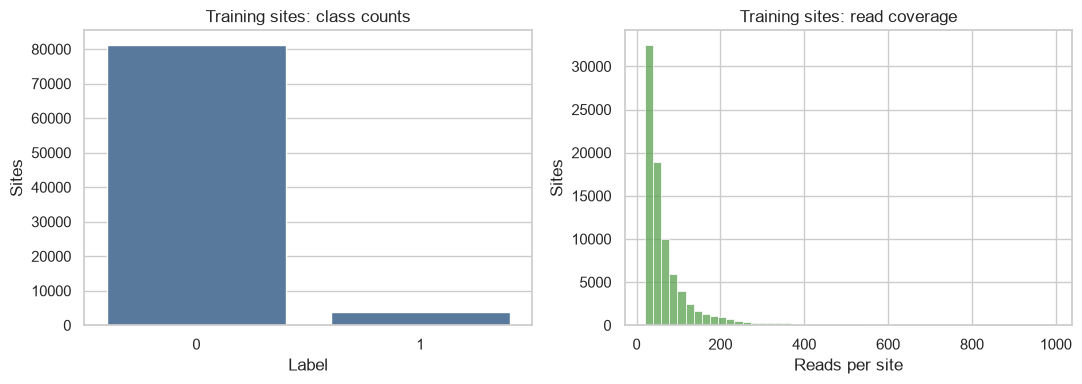

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,81337.0,91.364865,139.276057,20.0,32.0,48.0,85.0,991.0
1,3763.0,93.661175,138.678426,20.0,33.0,49.0,88.0,966.0


In [5]:
train_sites = sites.loc[sites["split"].eq("train")].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=train_sites, x="label", ax=axes[0], color="#4c78a8")
axes[0].set(title="Training sites: class counts", xlabel="Label", ylabel="Sites")
sns.histplot(data=train_sites, x="n_reads", bins=50, ax=axes[1], color="#59a14f")
axes[1].set(title="Training sites: read coverage", xlabel="Reads per site", ylabel="Sites")
plt.tight_layout()
plt.show()
display(train_sites.groupby("label")["n_reads"].describe())


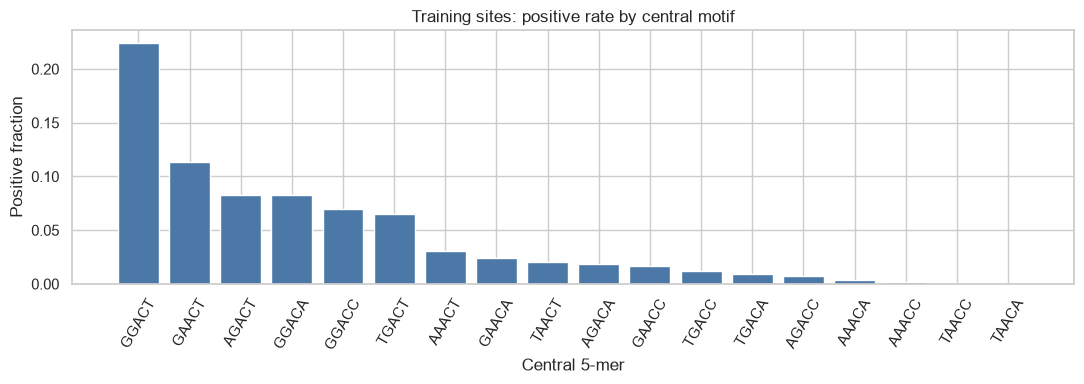

,sites,positives,positive_rate
central_5mer,,,
GGACT,4492,1009,0.224622
GAACT,4806,544,0.113192
AGACT,4460,370,0.082960
GGACA,5315,438,0.082408
GGACC,5258,369,0.070179
TGACT,4718,305,0.064646
AAACT,5967,183,0.030669
GAACA,5437,130,0.023910
TAACT,3093,62,0.020045


In [6]:
motif_summary = (
    train_sites.groupby("central_5mer")["label"]
    .agg(sites="size", positives="sum", positive_rate="mean")
    .sort_values("positive_rate", ascending=False)
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(motif_summary.index, motif_summary["positive_rate"], color="#4c78a8")
ax.set(title="Training sites: positive rate by central motif", xlabel="Central 5-mer", ylabel="Positive fraction")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()
display(motif_summary)


## 5. Site feature engineering and the raw-mean baseline

Reuse `build_features` to create the existing **153 engineered features**: log dwell, centre/flank contrasts, site summaries,
coverage, position-wise sequence and central motif encodings. Separately compute the **arithmetic mean of each of the nine raw signals** at each site.
These nine extra columns define the mean-only boosting baseline; they do not include sequence, coverage, transformed dwell or higher-order statistics.

The shared feature table has 162 columns, but pipelines select exactly one feature set. The full engineered models continue to use 153 columns.
All aggregations are site-local and all categorical encodings are fixed. No population statistics are fitted before CV.
Optional k-mer residuals remain disabled; adding them would require fitting baselines separately inside each fold.

Read batches retain complete sites even when a site crosses a batch boundary. Metadata consistency, coverage and finite signals are checked.


In [7]:
def iter_complete_site_batches(path, batch_size=BATCH_SIZE):
    """Yield complete sites, carrying the final site across read batches."""
    if batch_size < 1:
        raise ValueError("batch_size must be positive.")
    carry = None
    for record_batch in pq.ParquetFile(path).iter_batches(
        batch_size=batch_size, columns=required_columns,
    ):
        frame = record_batch.to_pandas()
        if carry is not None:
            frame = pd.concat([carry, frame], ignore_index=True)
        last = frame.iloc[-1]
        is_last_site = (
            frame["transcript_id"].eq(last["transcript_id"])
            & frame["transcript_position"].eq(last["transcript_position"])
        )
        carry = frame.loc[is_last_site].copy()
        complete = frame.loc[~is_last_site].copy()
        if not complete.empty:
            yield complete
    if carry is not None and not carry.empty:
        yield carry


def validate_read_batch(frame):
    """Validate signals, repeated metadata and complete per-site coverage."""
    if frame[required_columns].isna().any().any():
        raise ValueError("Read data contains missing values.")
    if not np.isfinite(frame[RAW_FEATURE_NAMES].to_numpy()).all():
        raise ValueError("Signals contain non-finite values.")
    dwell_cols = [name for name in RAW_FEATURE_NAMES if name.endswith("_dwell")]
    if not frame[dwell_cols].gt(0).all().all():
        raise ValueError("Dwell must be positive before log transformation.")
    if not frame["label"].isin([0, 1]).all():
        raise ValueError("Read labels are not binary.")
    if frame.duplicated([*SITE_KEY_COLUMNS, "read_idx"]).any():
        raise ValueError("Duplicate read_idx within a site.")
    grouped = frame.groupby(SITE_KEY_COLUMNS, sort=False)
    repeated = ["sequence", "n_reads", "gene_id", "label"]
    if not grouped[repeated].nunique(dropna=False).eq(1).all().all():
        raise ValueError("Inconsistent metadata within a site.")
    if not grouped.size().eq(grouped["n_reads"].first()).all():
        raise ValueError("Incomplete site reads; use a Parquet generated by the project parser without reordering.")


feature_parts = []
processed_reads = 0
for batch_number, read_batch in enumerate(iter_complete_site_batches(READS_PATH), start=1):
    validate_read_batch(read_batch)
    # Pass feature inputs only; exclude label and gene_id from feature engineering.
    engineered = build_features(
        read_batch[[*SITE_KEY_COLUMNS, "sequence", "n_reads", *RAW_FEATURE_NAMES]]
    ).set_index(SITE_KEY_COLUMNS)
    raw_means = read_batch.groupby(SITE_KEY_COLUMNS)[RAW_FEATURE_NAMES].mean()
    raw_means.columns = RAW_MEAN_COLUMNS
    feature_parts.append(engineered.join(raw_means, validate="one_to_one").reset_index())
    processed_reads += len(read_batch)
    if batch_number % 10 == 0:
        print(f"Processed {processed_reads:,} reads")

assert processed_reads == parquet_file.metadata.num_rows
site_features = pd.concat(feature_parts, ignore_index=True)
assert not site_features.duplicated(SITE_KEY_COLUMNS).any(), "A site appears in non-contiguous batches."
site_features = site_features.set_index(SITE_KEY_COLUMNS).sort_index()
site_metadata = sites.set_index(SITE_KEY_COLUMNS).sort_index()
assert site_features.index.equals(site_metadata.index), "Feature and label site identities do not match."
assert site_features["n_reads"].eq(site_metadata["n_reads"]).all()
assert list(site_features.columns) == MODEL_FEATURE_COLUMNS
assert np.isfinite(site_features.to_numpy()).all()
del feature_parts, read_batch
gc.collect()
print(f"Complete: {len(site_features):,} sites × {len(MODEL_FEATURE_COLUMNS)} available columns")


Processed 1,999,997 reads
Processed 3,999,231 reads
Processed 5,999,895 reads
Processed 7,999,946 reads
Processed 9,999,241 reads
Complete: 121,838 sites × 162 available columns


## 6. Prepare X_train / y_train, X_val / y_val and X_test / y_test

X is a numeric DataFrame and y is an `int8` Series, sharing the same ordered site MultiIndex.
Site identifiers remain in the index for prediction alignment, **not in feature columns**.
Use `.to_numpy()` if needed, while preserving row order.


In [8]:
def make_xy(split_name):
    meta = site_metadata.loc[site_metadata["split"].eq(split_name)].copy()
    X = site_features.loc[meta.index, MODEL_FEATURE_COLUMNS].copy()
    y = meta["label"].astype("int8").rename("label").copy()
    # Retain metadata to map predictions back to genes and sites.
    meta = meta.drop(columns="label")
    assert X.index.equals(y.index) and X.index.equals(meta.index)
    assert X.index.is_unique and not X.empty
    assert y.isin([0, 1]).all() and y.nunique() == 2
    assert np.isfinite(X.to_numpy()).all()
    assert all(pd.api.types.is_numeric_dtype(dtype) for dtype in X.dtypes)
    assert set(X.columns).isdisjoint({"label", "gene_id", "transcript_id", "transcript_position", "split"})
    return X, y, meta

X_train, y_train, metadata_train = make_xy("train")
X_val, y_val, metadata_val = make_xy("val")
X_test, y_test, metadata_test = make_xy("test")

assert X_train.columns.equals(X_val.columns) and X_train.columns.equals(X_test.columns)
assert len(X_train) + len(X_val) + len(X_test) == len(sites)
assert sites["split"].equals(assign_gene_splits(sites)), "The same seed must reproduce the split."

prepared = {
    "train": (X_train, y_train, metadata_train),
    "val": (X_val, y_val, metadata_val),
    "test": (X_test, y_test, metadata_test),
}
display(pd.DataFrame([
    {"split": name, "X_shape": X.shape, "y_shape": y.shape,
     "positives": int(y.sum()), "positive_rate": float(y.mean())}
    for name, (X, y, meta) in prepared.items()
]).set_index("split"))
display(X_train.head(), y_train.head())


,X_shape,y_shape,positives,positive_rate
split,,,,
train,"(85100, 162)","(85100,)",3763,0.044219
val,"(18352, 162)","(18352,)",935,0.050948
test,"(18386, 162)","(18386,)",777,0.042260


n_reads  minus1_log_dwell_mean  \
transcript_id   transcript_position                                   
ENST00000000233 244                      185              -4.980341   
                261                      172              -5.149516   
                316                      185              -5.030621   
                332                      200              -4.697330   
                368                      198              -4.738669   

                                     minus1_log_dwell_sd  \
transcript_id   transcript_position                        
ENST00000000233 244                             0.606104   
                261                             0.507048   
                316                             0.535148   
                332                             0.557276   
                368                             0.643782   

                                     minus1_log_dwell_min  \
transcript_id   transcript_position                         
ENST00000000233 244                             -6.219621   
                261                             -6.219621   
                316                             -6.066188   
                332                             -6.066188   
                368                             -6.219621   

                                     minus1_log_dwell_max  \
transcript_id   transcript_position                         
ENST00000000233 244                             -3.384340   
                261                             -3.807663   
                316                             -3.509897   
                332                             -3.296837   
                368                             -3.040730   

                                     minus1_log_dwell_p25  ...  \
transcript_id   transcript_position                        ...   
ENST00000000233 244                             -5.444500  ...   
                261                             -5.444500  ...   
                316                             -5.426151  ...   
                332                             -5.039815  ...   
                368                             -5.155195  ...   

                                     raw_mean__central_dwell  \
transcript_id   transcript_position                            
ENST00000000233 244                                 0.009373   
                261                                 0.006813   
                316                                 0.007416   
                332                                 0.008632   
                368                                 0.011479   

                                     raw_mean__central_signal_sd  \
transcript_id   transcript_position                                
ENST00000000233 244                                     7.382162   
                261                                     3.226535   
                316                                     3.642703   
                332                                     2.899200   
                368                                     5.870303   

                                     raw_mean__central_signal_mean  \
transcript_id   transcript_position                                  
ENST00000000233 244                                     125.913514   
                261                                     107.889535   
                316                                      98.947027   
                332                                      97.836500   
                368                                     121.954545   

                                     raw_mean__plus1_dwell  \
transcript_id   transcript_position                          
ENST00000000233 244                               0.007345   
                261                               0.007710   
                316                               0.007555   
                332                               0.006101   
          

transcript_id    transcript_position
ENST00000000233  244                    0
                 261                    0
                 316                    0
                 332                    0
                 368                    0
Name: label, dtype: int8

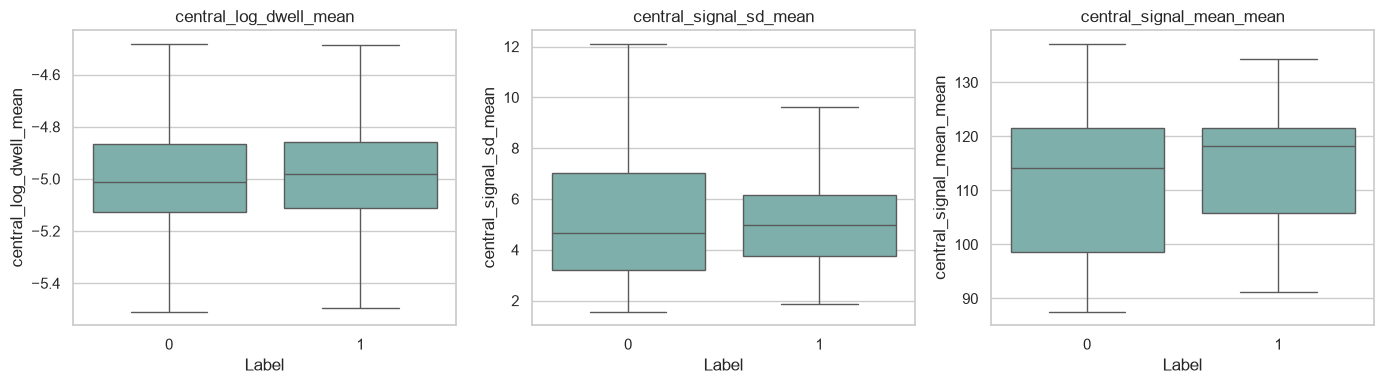

,count,mean,std,min,25%,50%,75%,max
central_log_dwell_mean,85100.0,-4.986152,0.193166,-5.63477,-5.124615,-5.008813,-4.867523,-4.037012
central_signal_sd_mean,85100.0,5.171303,2.188574,1.55430,3.226800,4.699195,6.983217,12.105000
central_signal_mean_mean,85100.0,111.002712,12.463550,87.52449,98.821714,114.705214,121.577543,137.120000
n_reads,85100.0,91.466404,139.249673,20.00000,32.000000,48.000000,85.000000,991.000000


In [9]:
# Inspect training features only: each observation represents a site.
central_features = ["central_log_dwell_mean", "central_signal_sd_mean", "central_signal_mean_mean"]
train_feature_eda = X_train[central_features].join(y_train)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, central_features):
    sns.boxplot(data=train_feature_eda, x="label", y=feature, showfliers=False, ax=ax, color="#76b7b2")
    ax.set(title=feature, xlabel="Label")
plt.tight_layout()
plt.show()
display(X_train[central_features + ["n_reads"]].describe().T)


## 7. Save this run's prepared inputs

Each run has its own directory under `data/processed/modelling/data0_gene_split_seed42/person_c_runs/`.
Save X, y, aligned metadata, the split manifest and configuration. Previous runs are not overwritten.
The X tables have 162 available columns, with feature selection performed inside each model pipeline.
Set `SAVE_OUTPUTS = False` only for an in-memory trial; the default saves the required experiment log and trained model.


In [10]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, (X, y, meta) in prepared.items():
        X.to_parquet(OUTPUT_DIR / f"X_{name}.parquet", index=True)
        y.to_frame().to_parquet(OUTPUT_DIR / f"y_{name}.parquet", index=True)
        meta.to_parquet(OUTPUT_DIR / f"metadata_{name}.parquet", index=True)
    sites.to_parquet(OUTPUT_DIR / "split_manifest.parquet", index=False)
    config = {
        "run_id": RUN_ID, "dataset": "data0", "seed": SEED, "group_column": "gene_id",
        "requested_gene_fractions": dict(zip(SPLIT_NAMES, SPLIT_RATIOS)),
        "feature_columns": MODEL_FEATURE_COLUMNS, "kmer_residuals": False,
        "source_parquet": str(READS_PATH.relative_to(ROOT)),
        "source_size_bytes": READS_PATH.stat().st_size,
        "source_mtime_ns": READS_PATH.stat().st_mtime_ns,
        "split_summary": split_summary.to_dict(orient="index"),
    }
    (OUTPUT_DIR / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

    # Check a save/load round trip for index, column order and label dtype.
    restored_X = pd.read_parquet(OUTPUT_DIR / "X_val.parquet")
    restored_y = pd.read_parquet(OUTPUT_DIR / "y_val.parquet")["label"]
    pd.testing.assert_frame_equal(restored_X, X_val)
    pd.testing.assert_series_equal(restored_y, y_val)
    del restored_X, restored_y
    print("Saved:", OUTPUT_DIR)
else:
    print("No files exported; X and y are ready in this kernel.")


Saved: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/data0_gene_split_seed42/person_c_runs/20261004T183731_5bbdbfb1


## 8. One shared GroupKFold framework

Construct **five folds within X_train only**, using `gene_id` as the group. All experiments reuse these exact folds.
Every gene appears in one assessment fold, and each training site receives one out-of-fold prediction per experiment.
Scaling and class weighting are fitted/calculated from that fold's fitting partition only. Boosting uses fixed iteration counts with no internal random validation split.

Report the arithmetic mean and **sample standard deviation (ddof=1)** across the five fold metrics:
**ROC-AUC**, **PR-AUC (trapezoidal)** and **average precision (AP)**. AP and trapezoidal PR-AUC are different summaries of the PR curve.
Model selection uses mean **AP**, which is less misleading for a constant-score baseline; ROC-AUC breaks ties.
These are development CV scores used for selection, not nested-CV estimates or confidence intervals.


In [11]:
def make_group_folds(X, y, genes, n_splits=CV_FOLDS, seed=SEED):
    if not X.index.equals(y.index) or not X.index.equals(genes.index):
        raise ValueError("X, y and gene metadata must have the same ordered index.")
    if genes.isna().any() or genes.nunique() < n_splits:
        raise ValueError("Need non-missing genes and at least n_splits distinct genes.")
    splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = list(splitter.split(X, y, groups=genes))
    seen = np.zeros(len(X), dtype=int)
    for fit_idx, assess_idx in folds:
        assert set(genes.iloc[fit_idx]).isdisjoint(genes.iloc[assess_idx])
        if y.iloc[fit_idx].nunique() != 2 or y.iloc[assess_idx].nunique() != 2:
            raise ValueError("A fold lacks one class; review group composition before modelling.")
        seen[assess_idx] += 1
    assert (seen == 1).all()
    return folds

cv_groups = metadata_train["gene_id"]
cv_splits = make_group_folds(X_train, y_train, cv_groups)
cv_manifest = metadata_train[["gene_id"]].join(y_train)
cv_manifest["assessment_fold"] = -1
fold_details = []
for fold, (fit_idx, assess_idx) in enumerate(cv_splits, 1):
    cv_manifest.iloc[assess_idx, cv_manifest.columns.get_loc("assessment_fold")] = fold
    fold_details.append({
        "fold": fold, "fit_sites": len(fit_idx), "assessment_sites": len(assess_idx),
        "fit_genes": cv_groups.iloc[fit_idx].nunique(),
        "assessment_genes": cv_groups.iloc[assess_idx].nunique(),
        "fit_positive_rate": y_train.iloc[fit_idx].mean(),
        "assessment_positive_rate": y_train.iloc[assess_idx].mean(),
    })
assert cv_manifest.groupby("gene_id")["assessment_fold"].nunique().eq(1).all()
display(pd.DataFrame(fold_details).set_index("fold"))
if SAVE_OUTPUTS:
    cv_manifest.to_parquet(OUTPUT_DIR / "cv_fold_manifest.parquet")


,fit_sites,assessment_sites,fit_genes,assessment_genes,fit_positive_rate,assessment_positive_rate
fold,,,,,,
1,67438,17662,2156,540,0.043432,0.047220
2,67646,17454,2157,539,0.044304,0.043887
3,67543,17557,2157,539,0.044194,0.044313
4,69003,16097,2157,539,0.044317,0.043797
5,68770,16330,2157,539,0.044831,0.041641


In [12]:
def ranking_metrics(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(scores) != len(y_true) or not np.isfinite(scores).all():
        raise ValueError("Scores must be finite and aligned with labels.")
    precision, recall, _ = precision_recall_curve(y_true, scores)
    return {
        "average_precision": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc_trapezoid": auc(recall, precision),
    }

def threshold_metrics(y_true, scores, threshold):
    predicted = (np.asarray(scores) >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, predicted, zero_division=0),
        "recall": recall_score(y_true, predicted, zero_division=0),
        "f1": f1_score(y_true, predicted, zero_division=0),
        "specificity": tn / (tn + fp),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "accuracy": accuracy_score(y_true, predicted),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def positive_scores(estimator, X):
    positive_column = np.flatnonzero(estimator.classes_ == 1).item()
    with threadpool_limits(limits=MODEL_THREADS):
        scores = estimator.predict_proba(X)[:, positive_column]
    assert np.isfinite(scores).all() and ((scores >= 0) & (scores <= 1)).all()
    return scores

def select_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    denominator = precision[:-1] + recall[:-1]
    f1_values = np.divide(
        2 * precision[:-1] * recall[:-1], denominator,
        out=np.zeros_like(denominator), where=denominator > 0,
    )
    best_index = np.flatnonzero(f1_values == f1_values.max())[-1]
    table = pd.DataFrame({
        "threshold": thresholds, "precision": precision[:-1],
        "recall": recall[:-1], "f1": f1_values,
    })
    return float(thresholds[best_index]), table


## 9. Predeclare baselines, imbalance comparisons and hyperparameter search

| Experiments | Change |
|---|---|
| E00 | Constant training-prior reference |
| E01 → E02 | Raw-mean HGB baseline: unweighted → balanced class weights |
| E03 → E04 | Balanced logistic regression: sequence-only → all engineered features |
| E01 → E05 | HGB: nine raw means → 153 engineered features, keeping settings unweighted |
| E05 → E06 | Full HGB: unweighted → balanced class weights |
| E07 → E08 | Full XGBoost: scale_pos_weight=1 → fold-training negatives/positives |
| H01–H06 | Random HGB search over learning rate, iterations, leaves, leaf size, regularisation and weighting |
| X01–X06 | Random XGBoost search over learning rate, trees, depth, child weight, row/column sampling, regularisation and positive weighting |

Both searches are sampled with fixed seeds before seeing any CV results. They use the same five folds as the baselines.
For XGBoost, the `ratio` and `sqrt_ratio` strategies recompute negatives/positives using only the current fold's training labels.
No resampling is applied to assessment folds. Weighted model scores are not assumed to be calibrated probabilities.


In [13]:
FEATURE_SETS = {
    "raw_means": RAW_MEAN_COLUMNS,
    "sequence": [c for c in FEATURE_COLUMNS if c.startswith(("seq_pos", "motif_"))],
    "engineered": FEATURE_COLUMNS,
}
HGB_DEFAULTS = dict(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                    min_samples_leaf=30, l2_regularization=1.0)
XGB_DEFAULTS = dict(learning_rate=0.05, n_estimators=200, max_depth=4,
                    min_child_weight=1, subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0)
experiments = []

def add_experiment(experiment_id, family, feature_set, weighting, params, changed, parent=None, stage="baseline"):
    experiments.append({
        "experiment_id": experiment_id, "family": family, "feature_set": feature_set,
        "weighting": weighting, "params": dict(params), "changed": changed,
        "parent": parent, "stage": stage,
    })

add_experiment("E00", "dummy", "raw_means", "none", {}, "Constant training-prior reference")
add_experiment("E01", "hgb", "raw_means", "none", HGB_DEFAULTS, "Nine raw signal means; unweighted boosted-tree baseline")
add_experiment("E02", "hgb", "raw_means", "balanced", HGB_DEFAULTS, "Add balanced class weights", "E01")
add_experiment("E03", "logistic", "sequence", "balanced", {"C": 1.0}, "Sequence-only linear comparison")
add_experiment("E04", "logistic", "engineered", "balanced", {"C": 1.0}, "Replace sequence-only with 153 engineered features", "E03")
add_experiment("E05", "hgb", "engineered", "none", HGB_DEFAULTS, "Replace raw means with 153 engineered features", "E01")
add_experiment("E06", "hgb", "engineered", "balanced", HGB_DEFAULTS, "Add balanced class weights", "E05")
add_experiment("E07", "xgb", "engineered", "none", XGB_DEFAULTS, "Add XGBoost comparison with scale_pos_weight=1", "E05")
add_experiment("E08", "xgb", "engineered", "ratio", XGB_DEFAULTS, "Use fold-training negatives/positives as scale_pos_weight", "E07")

hgb_search_space = {
    "learning_rate": [0.03, 0.08], "max_iter": [200, 350], "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [20, 50], "l2_regularization": [0.0, 2.0], "weighting": ["none", "balanced"],
}
xgb_search_space = {
    "learning_rate": [0.03, 0.08], "n_estimators": [200, 350], "max_depth": [3, 5],
    "min_child_weight": [1, 5], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0], "weighting": ["none", "sqrt_ratio", "ratio"],
}
for family, prefix, space, base, parent, seed in [
    ("hgb", "H", hgb_search_space, HGB_DEFAULTS, "E05", SEED),
    ("xgb", "X", xgb_search_space, XGB_DEFAULTS, "E07", SEED + 1),
]:
    for number, sampled in enumerate(ParameterSampler(space, n_iter=SEARCH_CANDIDATES_PER_FAMILY, random_state=seed), 1):
        params = dict(sampled)
        weighting = params.pop("weighting")
        changes = {key: {"from": base[key], "to": value} for key, value in params.items() if base[key] != value}
        if weighting != "none": changes["weighting"] = {"from": "none", "to": weighting}
        add_experiment(f"{prefix}{number:02d}", family, "engineered", weighting, params,
                       json.dumps(changes, sort_keys=True), parent, "random_search")

assert len({e["experiment_id"] for e in experiments}) == len(experiments)
experiment_plan = pd.DataFrame([{**e, "params": json.dumps(e["params"], sort_keys=True),
                                 "n_features": len(FEATURE_SETS[e["feature_set"]])} for e in experiments])
print(f"Plan: {len(experiments)} experiments × {CV_FOLDS} folds = {len(experiments) * CV_FOLDS} fits")
display(experiment_plan[["experiment_id", "family", "feature_set", "n_features", "weighting", "stage"]])
if SAVE_OUTPUTS:
    experiment_plan.to_csv(OUTPUT_DIR / "experiment_plan.csv", index=False)


Plan: 21 experiments × 5 folds = 105 fits


,experiment_id,family,feature_set,n_features,weighting,stage
0,E00,dummy,raw_means,9,none,baseline
1,E01,hgb,raw_means,9,none,baseline
2,E02,hgb,raw_means,9,balanced,baseline
3,E03,logistic,sequence,47,balanced,baseline
4,E04,logistic,engineered,153,balanced,baseline
5,E05,hgb,engineered,153,none,baseline
6,E06,hgb,engineered,153,balanced,baseline
7,E07,xgb,engineered,153,none,baseline
8,E08,xgb,engineered,153,ratio,baseline
9,H01,hgb,engineered,153,none,random_search


In [14]:
def build_experiment_model(spec, y_fit):
    labels = np.asarray(y_fit)
    if set(np.unique(labels)) != {0, 1}:
        raise ValueError("Fitting labels must contain exactly classes 0 and 1.")
    negatives, positives = int((labels == 0).sum()), int((labels == 1).sum())
    ratio = negatives / positives
    family, weighting = spec["family"], spec["weighting"]
    params = dict(spec["params"])
    if family == "xgb":
        scale = {"none": 1.0, "ratio": ratio, "sqrt_ratio": np.sqrt(ratio)}[weighting]
        estimator = XGBClassifier(
            **params, objective="binary:logistic", eval_metric="logloss",
            tree_method="hist", n_jobs=MODEL_THREADS, random_state=SEED,
            scale_pos_weight=scale,
        )
    elif family == "hgb":
        estimator = HistGradientBoostingClassifier(
            **params, class_weight="balanced" if weighting == "balanced" else None,
            early_stopping=False, random_state=SEED,
        )
        scale = None
    elif family == "logistic":
        estimator = LogisticRegression(
            **params, class_weight="balanced" if weighting == "balanced" else None,
            solver="lbfgs", max_iter=2000, random_state=SEED,
        )
        scale = None
    elif family == "dummy":
        estimator = DummyClassifier(strategy="prior")
        scale = None
    else:
        raise ValueError(f"Unknown model family: {family}")
    steps = [("select", ColumnTransformer([
        ("features", "passthrough", FEATURE_SETS[spec["feature_set"]])
    ], remainder="drop"))]
    if family == "logistic": steps.append(("scale", StandardScaler()))
    steps.append(("classifier", estimator))
    realised = {
        "fit_negatives": negatives, "fit_positives": positives,
        "scale_pos_weight": scale,
        "class_weight_0": len(labels) / (2 * negatives) if weighting == "balanced" else 1.0,
        "class_weight_1": len(labels) / (2 * positives) if weighting == "balanced" else 1.0,
    }
    return Pipeline(steps), realised


def append_csv_records(records, path):
    """Append completed records; a new run directory keeps previous runs intact."""
    frame = pd.DataFrame(records)
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)


def run_cv_experiment(spec, X, y, genes, folds, save_dir=None):
    if not X.index.equals(y.index) or not X.index.equals(genes.index):
        raise ValueError("CV inputs must have matching ordered indices.")
    oof = np.full(len(y), np.nan)
    coverage = np.zeros(len(y), dtype=int)
    fold_rows = []
    for fold, (fit_idx, assess_idx) in enumerate(folds, 1):
        assert set(genes.iloc[fit_idx]).isdisjoint(genes.iloc[assess_idx])
        model, realised = build_experiment_model(spec, y.iloc[fit_idx])
        start = perf_counter()
        with threadpool_limits(limits=MODEL_THREADS), warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
        fit_seconds = perf_counter() - start
        scores = positive_scores(model, X.iloc[assess_idx])
        oof[assess_idx] = scores
        coverage[assess_idx] += 1
        row = {
            "run_id": RUN_ID, "experiment_id": spec["experiment_id"], "fold": fold,
            "fit_sites": len(fit_idx), "assessment_sites": len(assess_idx),
            "fit_genes": genes.iloc[fit_idx].nunique(), "assessment_genes": genes.iloc[assess_idx].nunique(),
            **realised, **ranking_metrics(y.iloc[assess_idx], scores),
            "fit_seconds": fit_seconds, "completed_at": datetime.now(LOCAL_TZ).isoformat(),
        }
        fold_rows.append(row)
        if save_dir is not None:
            append_csv_records([row], save_dir / "fold_results.csv")
        print(f"  {spec['experiment_id']} fold {fold}/{len(folds)}: ROC={row['roc_auc']:.4f}, PR-AUC={row['pr_auc_trapezoid']:.4f}, AP={row['average_precision']:.4f}", flush=True)
    assert (coverage == 1).all() and np.isfinite(oof).all()
    table = pd.DataFrame(fold_rows)
    summary = {
        "run_id": RUN_ID, "experiment_id": spec["experiment_id"], "stage": spec["stage"],
        "family": spec["family"], "feature_set": spec["feature_set"],
        "n_features": len(FEATURE_SETS[spec["feature_set"]]), "weighting": spec["weighting"],
        "parent": spec["parent"], "changed": spec["changed"],
        "params_json": json.dumps(spec["params"], sort_keys=True), "folds": len(folds),
        "total_fit_seconds": table["fit_seconds"].sum(),
        "completed_at": datetime.now(LOCAL_TZ).isoformat(),
    }
    for metric in ["roc_auc", "pr_auc_trapezoid", "average_precision"]:
        summary[f"{metric}_mean"] = table[metric].mean()
        summary[f"{metric}_sd"] = table[metric].std(ddof=1)
    if save_dir is not None:
        append_csv_records([summary], save_dir / "experiment_log.csv")
        pd.DataFrame({"gene_id": genes, "label": y, "oof_score": oof}).to_parquet(
            save_dir / f"oof_{spec['experiment_id']}.parquet", index=True,
        )
    return summary, table, oof


def rank_experiments(summary):
    return summary.sort_values(
        ["average_precision_mean", "roc_auc_mean", "experiment_id"],
        ascending=[False, False, True],
    ).reset_index(drop=True)


## 10. Run all experiments and keep an audit trail

Every fold is logged immediately after completion; every experiment records its change from the named parent, complete parameter values,
weight strategy and mean ± sd for both requested AUCs plus AP. Out-of-fold scores are saved for every candidate.
The run metadata records package versions, feature-engineering and input checksums, the code digest, fold count and selection rule.
Rerun from the setup cell (or Run All) to start a new experiment history; do not overwrite this run by rerunning the training cell alone.


In [15]:
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

versions = {"sklearn": sklearn.__version__, "xgboost": xgboost.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
notebook_path = ROOT / "notebooks/data0_modelling_pipeline.ipynb"
notebook_sources = [cell["source"] for cell in json.loads(notebook_path.read_text())["cells"]]
run_metadata = {
    "run_id": RUN_ID, "started_at": datetime.now(LOCAL_TZ).isoformat(),
    "timezone": str(LOCAL_TZ), "seed": SEED, "cv_folds": CV_FOLDS,
    "cv_partition": "train_only", "cv_group": "gene_id", "cv_shuffle": True,
    "selection_rule": "highest_mean_CV_AP_then_ROC_AUC_then_experiment_id",
    "sd_ddof": 1, "n_experiments": len(experiments), "versions": versions,
    "source_parquet_sha256": file_sha256(READS_PATH),
    "feature_engineering_sha256": file_sha256(ROOT / "src/feature_engineering.py"),
    "notebook_sources_sha256": hashlib.sha256(json.dumps(notebook_sources, sort_keys=True).encode()).hexdigest(),
    "test_status": "Previously inspected historical internal test; no current tuning uses it.",
}
if SAVE_OUTPUTS:
    with (OUTPUT_DIR / "cv_started.json").open("x", encoding="utf-8") as handle:
        json.dump(run_metadata, handle, indent=2)

experiment_summaries, all_fold_tables, oof_scores = [], [], {}
for spec in experiments:
    print(f"Starting {spec['experiment_id']}: {spec['family']} / {spec['feature_set']} / {spec['weighting']}", flush=True)
    summary, fold_table, scores = run_cv_experiment(
        spec, X_train, y_train, cv_groups, cv_splits,
        save_dir=OUTPUT_DIR if SAVE_OUTPUTS else None,
    )
    experiment_summaries.append(summary)
    all_fold_tables.append(fold_table)
    oof_scores[spec["experiment_id"]] = scores
    print(f"Completed {spec['experiment_id']}: AP {summary['average_precision_mean']:.4f} ± {summary['average_precision_sd']:.4f}", flush=True)

experiment_results = rank_experiments(pd.DataFrame(experiment_summaries))
fold_results = pd.concat(all_fold_tables, ignore_index=True)
assert len(fold_results) == len(experiments) * CV_FOLDS
best_experiment_id = experiment_results.iloc[0]["experiment_id"]
best_spec = next(spec for spec in experiments if spec["experiment_id"] == best_experiment_id)
best_model_name = f"{best_experiment_id}: {best_spec['family']} ({best_spec['feature_set']}, {best_spec['weighting']})"

if SAVE_OUTPUTS:
    experiment_results.to_csv(OUTPUT_DIR / "cv_leaderboard.csv", index=False)
    append_csv_records(experiment_summaries, OUTPUT_BASE / "person_c_experiment_history.csv")
    (OUTPUT_DIR / "cv_complete.json").write_text(json.dumps({
        "run_id": RUN_ID, "completed_at": datetime.now(LOCAL_TZ).isoformat(),
        "selected_experiment": best_experiment_id,
    }, indent=2))
print("CV-selected model:", best_model_name)


Starting E00: dummy / raw_means / none
  E00 fold 1/5: ROC=0.5000, PR-AUC=0.5236, AP=0.0472
  E00 fold 2/5: ROC=0.5000, PR-AUC=0.5219, AP=0.0439
  E00 fold 3/5: ROC=0.5000, PR-AUC=0.5222, AP=0.0443
  E00 fold 4/5: ROC=0.5000, PR-AUC=0.5219, AP=0.0438
  E00 fold 5/5: ROC=0.5000, PR-AUC=0.5208, AP=0.0416
Completed E00: AP 0.0442 ± 0.0020
Starting E01: hgb / raw_means / none
  E01 fold 1/5: ROC=0.8948, PR-AUC=0.4344, AP=0.4351
  E01 fold 2/5: ROC=0.8743, PR-AUC=0.4044, AP=0.4051
  E01 fold 3/5: ROC=0.8566, PR-AUC=0.3936, AP=0.3942
  E01 fold 4/5: ROC=0.8675, PR-AUC=0.3864, AP=0.3874
  E01 fold 5/5: ROC=0.8648, PR-AUC=0.3729, AP=0.3736
Completed E01: AP 0.3991 ± 0.0231
Starting E02: hgb / raw_means / balanced
  E02 fold 1/5: ROC=0.8931, PR-AUC=0.4263, AP=0.4268
  E02 fold 2/5: ROC=0.8690, PR-AUC=0.3881, AP=0.3888
  E02 fold 3/5: ROC=0.8561, PR-AUC=0.3904, AP=0.3909
  E02 fold 4/5: ROC=0.8695, PR-AUC=0.3824, AP=0.3831
  E02 fold 5/5: ROC=0.8643, PR-AUC=0.3680, AP=0.3693
Completed E02: AP 0.

## 11. Compare experiments and quantify changes

The table reports mean ± sample sd across the same five folds. The fold sd describes variation across assessment genes;
it is not a standard error or a 95% confidence interval. The selected maximum is subject to search selection optimism.
Trapezoidal PR-AUC of a constant predictor can be inflated by interpolation; use its AP (assessment prevalence) as the no-skill reference.
Paired changes below compare each variant against its declared parent on identical folds; they are descriptive, not significance tests.


,family,feature_set,weighting,ROC AUC mean ± sd,PR AUC (trapezoid) mean ± sd,AP mean ± sd
experiment_id,,,,,,
H04,hgb,engineered,none,0.9183 ± 0.0104,0.4825 ± 0.0320,0.4834 ± 0.0317
X05,xgb,engineered,none,0.9187 ± 0.0104,0.4806 ± 0.0283,0.4815 ± 0.0281
H06,hgb,engineered,none,0.9175 ± 0.0090,0.4793 ± 0.0281,0.4800 ± 0.0280
H01,hgb,engineered,none,0.9174 ± 0.0103,0.4785 ± 0.0307,0.4795 ± 0.0305
H02,hgb,engineered,none,0.9182 ± 0.0100,0.4753 ± 0.0269,0.4762 ± 0.0266
X06,xgb,engineered,none,0.9175 ± 0.0108,0.4751 ± 0.0327,0.4761 ± 0.0323
E05,hgb,engineered,none,0.9162 ± 0.0100,0.4736 ± 0.0269,0.4744 ± 0.0267
X01,xgb,engineered,none,0.9151 ± 0.0108,0.4697 ± 0.0253,0.4707 ± 0.0251
X04,xgb,engineered,sqrt_ratio,0.9173 ± 0.0104,0.4666 ± 0.0250,0.4675 ± 0.0249


,experiment_id,parent,changed,delta_roc_auc_mean,delta_roc_auc_sd,delta_pr_auc_trapezoid_mean,delta_pr_auc_trapezoid_sd,delta_average_precision_mean,delta_average_precision_sd
0,E02,E01,Add balanced class weights,-0.0012,0.0027,-0.0073,0.0053,-0.0073,0.0054
1,E04,E03,Replace sequence-only with 153 engineered feat...,0.0961,0.0105,0.2515,0.0266,0.2629,0.0244
2,E05,E01,Replace raw means with 153 engineered features,0.0446,0.0084,0.0753,0.0091,0.0753,0.0091
3,E06,E05,Add balanced class weights,0.0006,0.0006,-0.0207,0.0070,-0.0205,0.0067
4,E07,E05,Add XGBoost comparison with scale_pos_weight=1,-0.0006,0.0021,-0.0081,0.0041,-0.0080,0.0041
5,E08,E07,Use fold-training negatives/positives as scale...,-0.0013,0.0020,-0.0193,0.0127,-0.0192,0.0122


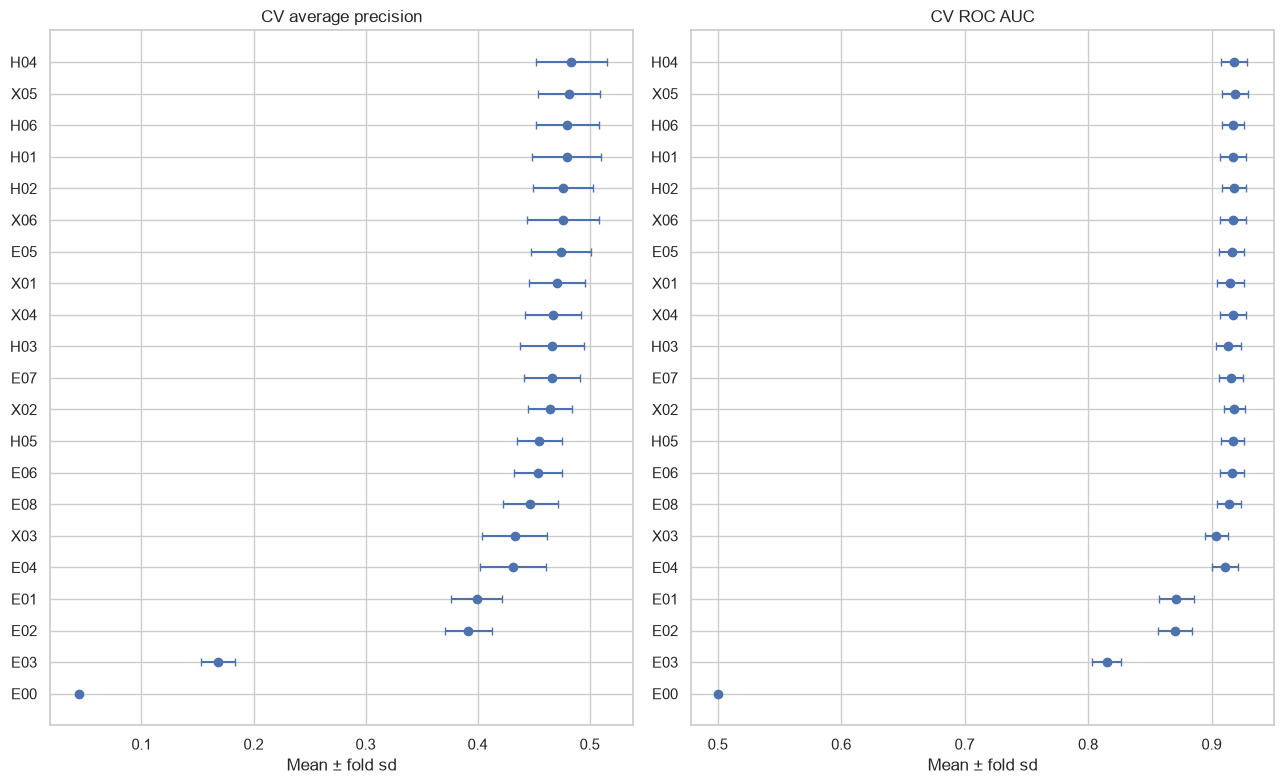

In [16]:
cv_display = experiment_results[["experiment_id", "family", "feature_set", "weighting"]].copy()
for metric, title in [("roc_auc", "ROC AUC"), ("pr_auc_trapezoid", "PR AUC (trapezoid)"), ("average_precision", "AP")]:
    cv_display[title + " mean ± sd"] = experiment_results.apply(
        lambda row: f"{row[metric + '_mean']:.4f} ± {row[metric + '_sd']:.4f}", axis=1,
    )
display(cv_display.set_index("experiment_id"))

paired_rows = []
for spec in experiments:
    if spec["parent"] is None:
        continue
    child = fold_results.loc[fold_results.experiment_id.eq(spec["experiment_id"])].set_index("fold")
    parent = fold_results.loc[fold_results.experiment_id.eq(spec["parent"])].set_index("fold")
    record = {"experiment_id": spec["experiment_id"], "parent": spec["parent"], "changed": spec["changed"]}
    for metric in ["roc_auc", "pr_auc_trapezoid", "average_precision"]:
        delta = child[metric] - parent[metric]
        record[f"delta_{metric}_mean"] = delta.mean()
        record[f"delta_{metric}_sd"] = delta.std(ddof=1)
    paired_rows.append(record)
paired_comparisons = pd.DataFrame(paired_rows)
display(paired_comparisons.loc[paired_comparisons.experiment_id.str.startswith("E")].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
plot_rows = experiment_results.iloc[::-1]
for ax, metric, title in zip(axes, ["average_precision", "roc_auc"], ["CV average precision", "CV ROC AUC"]):
    ax.errorbar(plot_rows[metric + "_mean"], np.arange(len(plot_rows)),
                xerr=plot_rows[metric + "_sd"], fmt="o", capsize=3)
    ax.set(yticks=np.arange(len(plot_rows)), yticklabels=plot_rows["experiment_id"],
           xlabel="Mean ± fold sd", title=title)
plt.tight_layout()
plt.show()
if SAVE_OUTPUTS:
    cv_display.to_csv(OUTPUT_DIR / "cv_mean_sd_report.csv", index=False)
    paired_comparisons.to_csv(OUTPUT_DIR / "paired_experiment_changes.csv", index=False)


## 12. Lock the CV winner, fit on all train, and select a validation threshold

Refit the selected configuration on X_train only. Also fit the predeclared prior, raw-mean HGB and sequence-logistic references for final comparison.
Model choice and hyperparameters are already fixed by CV; validation metrics are reported but do not reselect the model.
Choose the selected model's threshold using maximum validation F1 (largest threshold if tied).
Do not refit on train + validation afterward, because this would change the score distribution used to choose the threshold.


Locked model: H04: hgb (engineered, none); validation threshold: 0.186744


,average_precision,roc_auc,pr_auc_trapezoid
experiment_id,,,
E00,0.0509,0.5000,0.5255
E01,0.4210,0.8711,0.4205
E03,0.1818,0.8107,0.1921
H04,0.5098,0.9247,0.5088


,threshold,precision,recall,f1,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
rule,,,,,,,,,,,
default_0.5,0.5000,0.6538,0.3070,0.4178,0.9913,0.6491,0.9564,17265,152,648,287
validation_max_f1,0.1867,0.5132,0.5807,0.5449,0.9704,0.7756,0.9506,16902,515,392,543


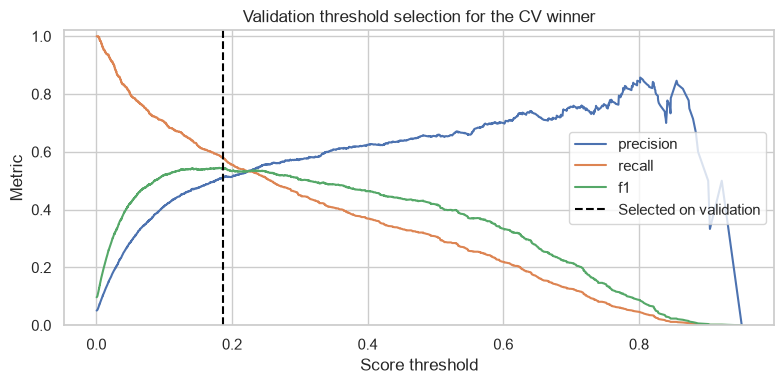

In [17]:
reference_ids = ["E00", "E01", "E03"]
final_ids = list(dict.fromkeys([*reference_ids, best_experiment_id]))
final_models, final_fit_rows, validation_scores = {}, [], {}
for experiment_id in final_ids:
    spec = next(spec for spec in experiments if spec["experiment_id"] == experiment_id)
    model, realised = build_experiment_model(spec, y_train)
    with threadpool_limits(limits=MODEL_THREADS), warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)
    final_models[experiment_id] = model
    final_fit_rows.append({"experiment_id": experiment_id, **realised})
    validation_scores[experiment_id] = positive_scores(model, X_val)
best_model = final_models[best_experiment_id]
best_val_scores = validation_scores[best_experiment_id]
validation_results = pd.DataFrame([
    {"experiment_id": name, **ranking_metrics(y_val, scores)}
    for name, scores in validation_scores.items()
]).set_index("experiment_id")
chosen_threshold, threshold_search = select_f1_threshold(y_val, best_val_scores)
validation_threshold_results = pd.DataFrame([
    {"rule": "default_0.5", **threshold_metrics(y_val, best_val_scores, 0.5)},
    {"rule": "validation_max_f1", **threshold_metrics(y_val, best_val_scores, chosen_threshold)},
]).set_index("rule")
print(f"Locked model: {best_model_name}; validation threshold: {chosen_threshold:.6f}")
display(validation_results.round(4), validation_threshold_results.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["precision", "recall", "f1"]:
    ax.plot(threshold_search["threshold"], threshold_search[metric], label=metric)
ax.axvline(chosen_threshold, color="black", linestyle="--", label="Selected on validation")
ax.set(title="Validation threshold selection for the CV winner", xlabel="Score threshold", ylabel="Metric", ylim=(0, 1.02))
ax.legend()
plt.tight_layout()
plt.show()


## 13. Final evaluation on the historical test partition

The experiment ID, hyperparameters and threshold are fixed before this cell. Compare the winner against predeclared references;
do not pick another winner from the test table. Report ROC-AUC, trapezoidal PR-AUC, AP, precision, recall, F1 and a confusion matrix.
Because this same test set was previously inspected, treat these as descriptive internal test results, not evidence from a newly untouched external cohort.


In [18]:
test_model_names = final_ids
test_scores = {
    name: positive_scores(final_models[name], X_test) for name in test_model_names
}
test_ranking_results = pd.DataFrame([
    {"model": name, **ranking_metrics(y_test, scores)}
    for name, scores in test_scores.items()
]).set_index("model")
test_ranking_results["selected_by_cv"] = test_ranking_results.index == best_experiment_id

best_test_scores = test_scores[best_experiment_id]
test_threshold_results = pd.DataFrame([
    {"rule": "default_0.5", **threshold_metrics(y_test, best_test_scores, 0.5)},
    {"rule": "validation_max_f1", **threshold_metrics(y_test, best_test_scores, chosen_threshold)},
]).set_index("rule")
test_predictions = metadata_test.join(y_test).assign(
    score=best_test_scores,
    prediction=(best_test_scores >= chosen_threshold).astype("int8"),
)
assert test_predictions.index.equals(y_test.index)
assert test_predictions["label"].equals(y_test)

print(f"Test sites: {len(y_test):,}; positive fraction: {y_test.mean():.4f}")
print(f"Final model: {best_model_name}; threshold selected on validation: {chosen_threshold:.6f}")
display(test_ranking_results.round(4), test_threshold_results.round(4))
test_classification_report = pd.DataFrame(classification_report(
    y_test, test_predictions["prediction"], labels=[0, 1],
    target_names=["unmodified (0)", "modified (1)"], zero_division=0, output_dict=True,
)).T
display(test_classification_report.round(4))


Test sites: 18,386; positive fraction: 0.0423
Final model: H04: hgb (engineered, none); threshold selected on validation: 0.186744


,average_precision,roc_auc,pr_auc_trapezoid,selected_by_cv
model,,,,
E00,0.0423,0.5000,0.5211,False
E01,0.4160,0.8844,0.4151,False
E03,0.1568,0.8191,0.1651,False
H04,0.4973,0.9279,0.4967,True


,threshold,precision,recall,f1,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
rule,,,,,,,,,,,
default_0.5,0.5000,0.6359,0.3372,0.4407,0.9915,0.6643,0.9638,17459,150,515,262
validation_max_f1,0.1867,0.4721,0.5997,0.5283,0.9704,0.7851,0.9547,17088,521,311,466


,precision,recall,f1-score,support
unmodified (0),0.9821,0.9704,0.9762,17609.0000
modified (1),0.4721,0.5997,0.5283,777.0000
accuracy,0.9547,0.9547,0.9547,0.9547
macro avg,0.7271,0.7851,0.7523,18386.0000
weighted avg,0.9606,0.9547,0.9573,18386.0000


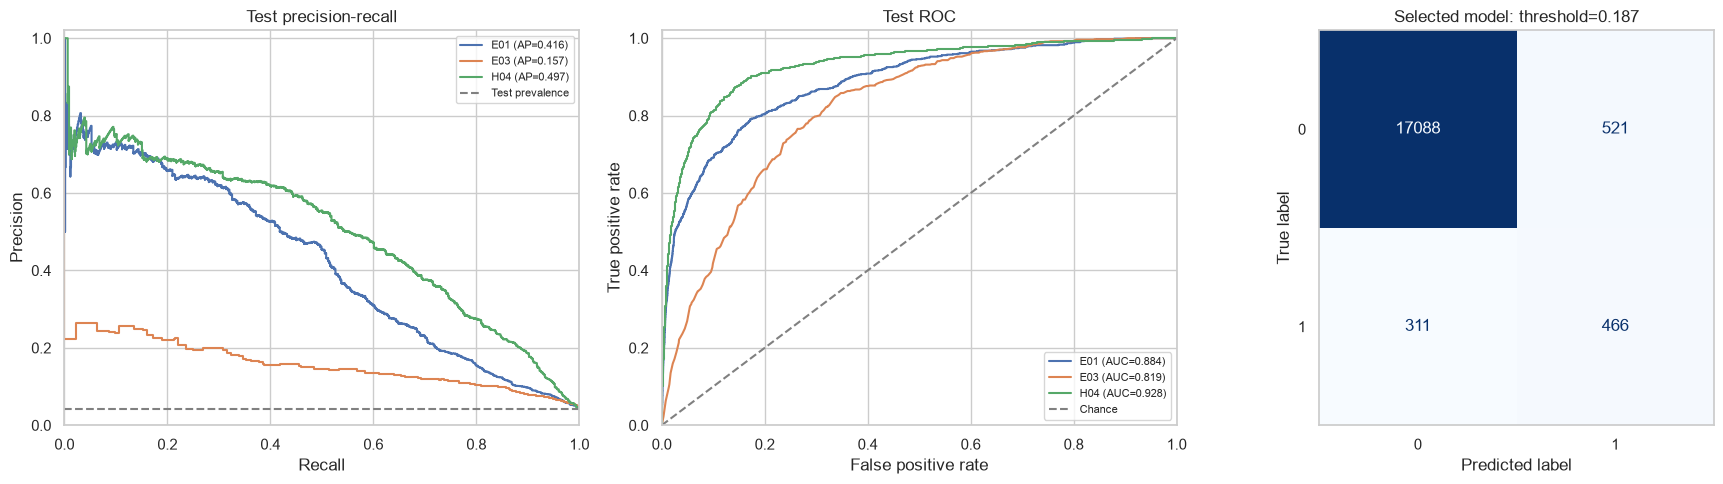

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, scores in test_scores.items():
    if name == "E00":
        continue  # Show its no-skill references as lines instead.
    precision, recall, _ = precision_recall_curve(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)
    ap = test_ranking_results.loc[name, "average_precision"]
    roc = test_ranking_results.loc[name, "roc_auc"]
    axes[0].step(recall, precision, where="post", label=f"{name} (AP={ap:.3f})")
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="Test prevalence")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance")
axes[0].set(title="Test precision-recall", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.02))
axes[1].set(title="Test ROC", xlabel="False positive rate", ylabel="True positive rate", xlim=(0, 1), ylim=(0, 1.02))
for ax in axes[:2]:
    ax.legend(fontsize=8, loc="best")
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions["prediction"], labels=[0, 1],
    display_labels=["0", "1"], values_format="d", colorbar=False,
    cmap="Blues", ax=axes[2],
)
axes[2].set_title(f"Selected model: threshold={chosen_threshold:.3f}")
axes[2].grid(False)
plt.tight_layout()
plt.show()


## 14. Gene-bootstrap intervals for the fixed selected model

Resample whole test genes (500 repeats), carrying all their sites together, to estimate 95% percentile intervals for AP, ROC-AUC and F1.
These conditional intervals describe variability among historical test genes for this fitted model. They do not include model fitting/selection uncertainty.
They are separate from the **CV mean ± sd** report above and do not replace it.


In [20]:
def gene_bootstrap_metrics(y_true, scores, genes, threshold, n_bootstrap=BOOTSTRAP_REPEATS, seed=SEED):
    if not y_true.index.equals(genes.index):
        raise ValueError("Gene metadata must align with the label index.")
    if genes.isna().any() or n_bootstrap < 1:
        raise ValueError("Genes must be populated and n_bootstrap must be positive.")
    codes, unique_genes = pd.factorize(genes, sort=True)
    rng = np.random.default_rng(seed)
    labels = y_true.to_numpy()
    predictions = (np.asarray(scores) >= threshold).astype("int8")
    samples = []
    for _ in range(n_bootstrap):
        gene_counts = np.bincount(
            rng.integers(0, len(unique_genes), size=len(unique_genes)),
            minlength=len(unique_genes),
        )
        weights = gene_counts[codes]
        if np.unique(labels[weights > 0]).size != 2:
            continue
        samples.append({
            "average_precision": average_precision_score(labels, scores, sample_weight=weights),
            "roc_auc": roc_auc_score(labels, scores, sample_weight=weights),
            "f1": f1_score(labels, predictions, sample_weight=weights, zero_division=0),
        })
    if len(samples) < 0.9 * n_bootstrap:
        raise ValueError("Too many bootstrap samples lack both classes for reliable intervals.")
    return pd.DataFrame(samples)

bootstrap_samples = gene_bootstrap_metrics(
    y_test, best_test_scores, metadata_test["gene_id"], chosen_threshold,
)
point_estimates = {
    "average_precision": test_ranking_results.loc[best_experiment_id, "average_precision"],
    "roc_auc": test_ranking_results.loc[best_experiment_id, "roc_auc"],
    "f1": test_threshold_results.loc["validation_max_f1", "f1"],
}
test_confidence_intervals = pd.DataFrame({
    "estimate": pd.Series(point_estimates),
    "lower_95": bootstrap_samples.quantile(0.025),
    "upper_95": bootstrap_samples.quantile(0.975),
})
print(f"Valid gene-bootstrap samples: {len(bootstrap_samples)} / {BOOTSTRAP_REPEATS}")
display(test_confidence_intervals.round(4))


Valid gene-bootstrap samples: 500 / 500


,estimate,lower_95,upper_95
average_precision,0.4973,0.4397,0.5554
roc_auc,0.9279,0.9150,0.9409
f1,0.5283,0.4858,0.5731


## 15. Recommend the final model and save the complete experiment record

The recommendation is determined by training CV, with validation used only for the threshold. Save the evaluated train-only model with its preprocessing,
feature schema, experiment specification, threshold, package versions, data lineage and known evaluation limitations.
Every run contains its own results log; a cumulative history CSV also records completed experiments from all runs.
This completes the Person C technical deliverables without backdating execution or treating the historical test as unseen data.


In [21]:
selected_cv = experiment_results.set_index("experiment_id").loc[best_experiment_id]
mean_baseline_cv = experiment_results.set_index("experiment_id").loc["E01"]
recommendation = {
    "run_id": RUN_ID, "recommended_at": datetime.now(LOCAL_TZ).isoformat(),
    "selected_experiment": best_experiment_id, "model_name": best_model_name,
    "specification": best_spec,
    "selection_reason": "Highest mean five-fold gene-grouped training CV AP; ROC-AUC breaks ties.",
    "cv_metrics": {name: float(selected_cv[name]) for name in selected_cv.index
                   if name.endswith(("_mean", "_sd"))},
    "cv_ap_gain_over_raw_mean_baseline": float(selected_cv.average_precision_mean - mean_baseline_cv.average_precision_mean),
    "validation_threshold": chosen_threshold,
    "historical_test_ranking": test_ranking_results.loc[best_experiment_id].to_dict(),
    "historical_test_threshold_metrics": test_threshold_results.loc["validation_max_f1"].to_dict(),
    "limitations": [
        "CV scores were used for tuning and selection; they are not nested-CV unbiased performance estimates.",
        "The internal test set was inspected in previous work; new external validation is still needed.",
        "Weighted scores are not guaranteed to be calibrated modification probabilities.",
        "No claim is made that the original September/October deadlines were met.",
    ],
}
recommendation_text = (
    f"**Recommended model: {best_model_name}.**\n\n"
    f"Five-fold gene-grouped CV: ROC-AUC **{selected_cv.roc_auc_mean:.4f} ± {selected_cv.roc_auc_sd:.4f}**, "
    f"PR-AUC (trapezoid) **{selected_cv.pr_auc_trapezoid_mean:.4f} ± {selected_cv.pr_auc_trapezoid_sd:.4f}**, "
    f"AP **{selected_cv.average_precision_mean:.4f} ± {selected_cv.average_precision_sd:.4f}**. "
    f"Mean AP changes by **{recommendation['cv_ap_gain_over_raw_mean_baseline']:+.4f}** relative to the raw-mean HGB baseline.\n\n"
    f"Use the validation-selected threshold **{chosen_threshold:.4f}** for the reported precision/recall trade-off. "
    "This recommendation uses CV scores, not test ranking. Historical test results are descriptive internal checks."
)
display(Markdown(recommendation_text))

model_bundle = {
    "model": best_model, "model_name": best_model_name, "experiment": best_spec,
    "threshold": chosen_threshold, "feature_columns": list(X_train.columns),
    "selected_feature_columns": FEATURE_SETS[best_spec["feature_set"]],
    "raw_mean_columns": RAW_MEAN_COLUMNS, "engineered_columns": FEATURE_COLUMNS,
    "seed": SEED, "selection_metric": "mean_training_GroupKFold_average_precision",
    "threshold_rule": "maximum_validation_f1_largest_threshold_on_tie",
    "training_partition": "train_only", "group_column": "gene_id",
    "kmer_residuals": False, "versions": versions, "run_id": RUN_ID,
}
if SAVE_OUTPUTS:
    joblib.dump(model_bundle, OUTPUT_DIR / "selected_model.joblib", compress=3)
    validation_results.to_csv(OUTPUT_DIR / "validation_ranking_metrics.csv")
    validation_threshold_results.to_csv(OUTPUT_DIR / "validation_threshold_metrics.csv")
    threshold_search.to_csv(OUTPUT_DIR / "validation_threshold_search.csv", index=False)
    test_ranking_results.to_csv(OUTPUT_DIR / "test_ranking_metrics.csv")
    test_threshold_results.to_csv(OUTPUT_DIR / "test_threshold_metrics.csv")
    test_classification_report.to_csv(OUTPUT_DIR / "test_classification_report.csv")
    test_confidence_intervals.to_csv(OUTPUT_DIR / "test_gene_bootstrap_intervals.csv")
    test_predictions.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=True)
    pd.DataFrame(final_fit_rows).to_csv(OUTPUT_DIR / "final_fit_weights.csv", index=False)
    (OUTPUT_DIR / "recommendation.json").write_text(json.dumps(recommendation, indent=2), encoding="utf-8")
    reloaded_bundle = joblib.load(OUTPUT_DIR / "selected_model.joblib")
    reloaded_scores = positive_scores(reloaded_bundle["model"], X_val[reloaded_bundle["feature_columns"]])
    np.testing.assert_allclose(reloaded_scores, best_val_scores, rtol=1e-12, atol=1e-12)
    assert reloaded_bundle["threshold"] == chosen_threshold
    pd.testing.assert_frame_equal(pd.read_csv(OUTPUT_DIR / "experiment_log.csv"),
                                  pd.DataFrame(experiment_summaries), check_dtype=False, atol=1e-12)
    print("PASS: saved experiment log and reloaded model verified.")
    print("Complete run directory:", OUTPUT_DIR)
    print("Cumulative experiment history:", OUTPUT_BASE / "person_c_experiment_history.csv")
else:
    print("Model, logs and recommendation remain in memory; enable SAVE_OUTPUTS to persist them.")


PASS: saved experiment log and reloaded model verified.
Complete run directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/data0_gene_split_seed42/person_c_runs/20261004T183731_5bbdbfb1
Cumulative experiment history: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/data0_gene_split_seed42/person_c_experiment_history.csv


**Recommended model: H04: hgb (engineered, none).**

Five-fold gene-grouped CV: ROC-AUC **0.9183 ± 0.0104**, PR-AUC (trapezoid) **0.4825 ± 0.0320**, AP **0.4834 ± 0.0317**. Mean AP changes by **+0.0843** relative to the raw-mean HGB baseline.

Use the validation-selected threshold **0.1867** for the reported precision/recall trade-off. This recommendation uses CV scores, not test ranking. Historical test results are descriptive internal checks.

## Deliverable map and interpretation

| Person C item | Evidence |
|---|---|
| GroupKFold by gene_id | `cv_fold_manifest.parquet`; disjoint-group assertions; five shared folds |
| ROC AUC / PR AUC mean ± sd | `cv_mean_sd_report.csv`, `cv_leaderboard.csv`, `fold_results.csv` |
| Mean-feature boosting baseline | Experiment E01: exactly nine arithmetic raw signal means |
| Class imbalance | E01/E02, E05/E06 and E07/E08 paired comparisons; logged fold-training weights |
| Hyperparameter tuning | H01–H06 and X01–X06; sampled search spaces and complete parameter records |
| Compare models | Identical CV folds, leaderboard and `paired_experiment_changes.csv` |
| Results log | `experiment_log.csv`, per-fold log and cumulative `person_c_experiment_history.csv` |
| Final recommendation | `recommendation.json`, displayed recommendation and `selected_model.joblib` |

Model evaluation is site-level. Independent genes, rather than read counts, determine the grouping and bootstrap units.
Higher AP does not imply that most positive predictions are correct; inspect the reported threshold, precision, recall and confusion matrix together.
For future experiments, use training CV for changes and seek external validation; do not repeatedly select changes based on the historical test results.
The separate m6Anet benchmark from the broader project handout is outside this Person C checklist.

References: [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html),
[average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html),
[XGBoost parameters and scale_pos_weight](https://xgboost.readthedocs.io/en/stable/parameter.html).
